In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
kagglehub.dataset_download('somesh24/spambase')

/kaggle/input/datasets/somesh24/spambase/spambase_csv.csv


'/kaggle/input/datasets/somesh24/spambase'

# Cell 1: Imports and Load Data

In [72]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, Binarizer, LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'savefig.dpi': 600,
})

sns.set(style="whitegrid")

def set_plot_style():
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 12,
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'savefig.dpi': 600,
    })

def save_current_plot(name, folder="figures", close=False):
    os.makedirs(folder, exist_ok=True)
    safe_name = re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name)).strip('_')
    fig = plt.gcf()
    path = os.path.join(folder, f"{safe_name}.eps")
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {path}")
    if close:
        plt.close(fig)
    return path

# Load dataset
csv_path = "/kaggle/input/datasets/somesh24/spambase/spambase_csv.csv"   # change this if your file name is different
df = pd.read_csv(csv_path)

# Cell 2: Basic Preprocessing

In [73]:
# Target column = last column
target_col = df.columns[-1]

# Encode target if it is not numeric
if df[target_col].dtype == "object":
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])

# Convert feature columns to numeric and handle missing values
for col in df.columns[:-1]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.fillna(df.median(numeric_only=True))

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

# Cell 3: Exploratory Data Analysis (EDA)

Saved: figures/class_distribution.eps


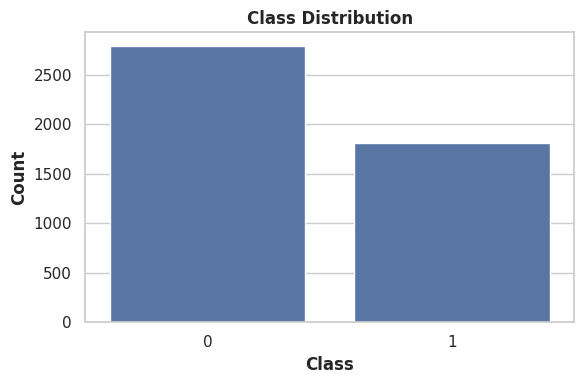

Saved: figures/correlation_heatmap.eps


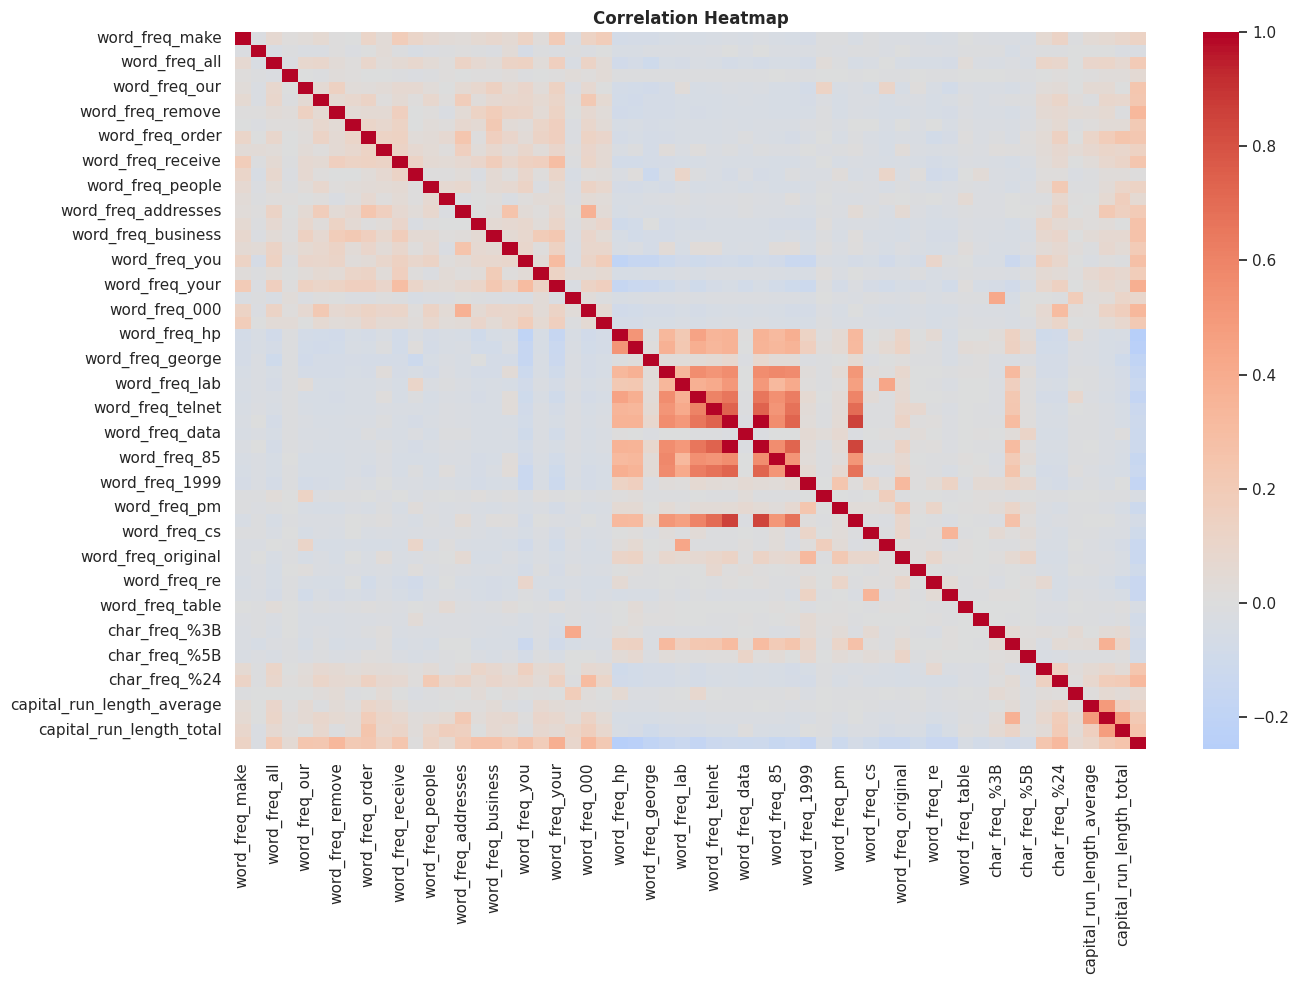

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/histogram_word_freq_your.eps


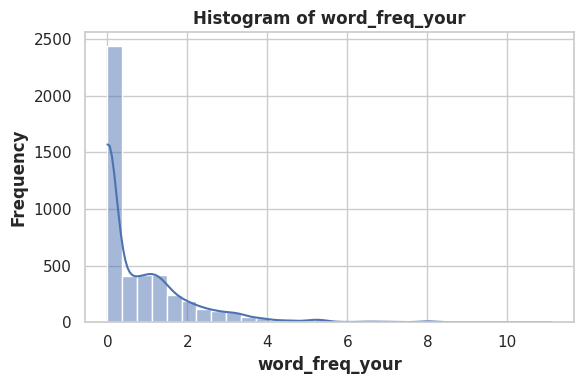

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/histogram_word_freq_000.eps


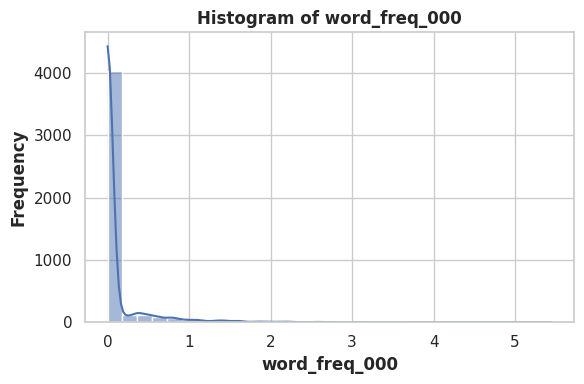

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/histogram_word_freq_remove.eps


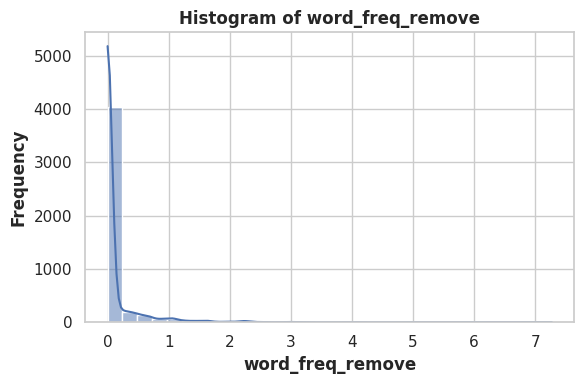

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/histogram_char_freq__24.eps


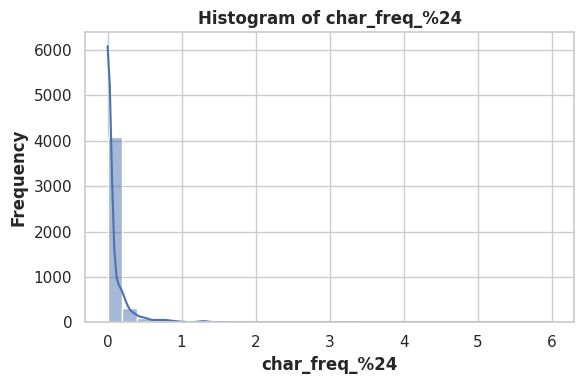

Saved: figures/boxplot_word_freq_your.eps


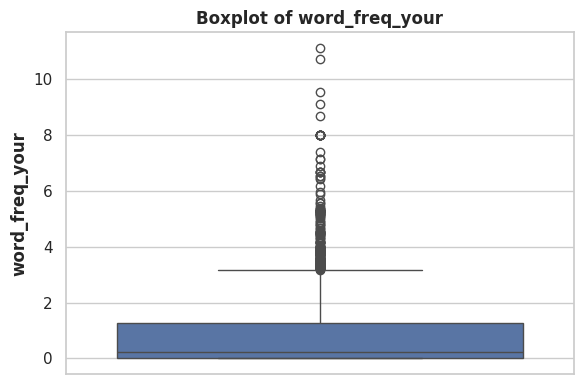

Saved: figures/boxplot_word_freq_000.eps


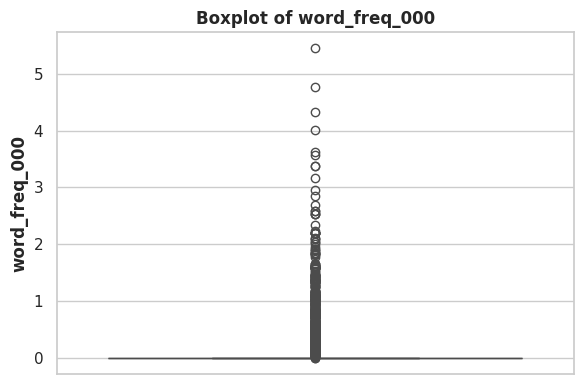

Saved: figures/boxplot_word_freq_remove.eps


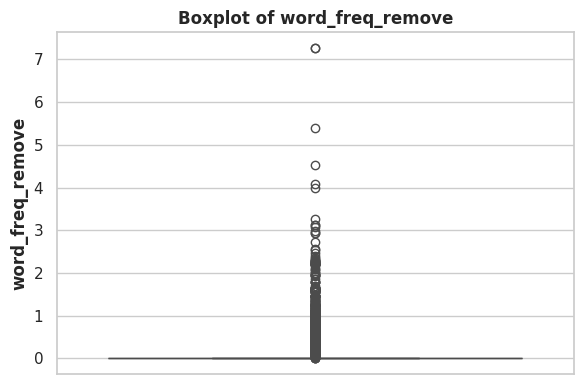

Saved: figures/boxplot_char_freq__24.eps


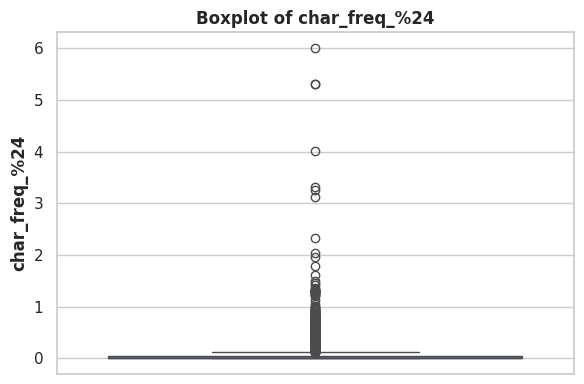

In [74]:
# 1) Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
save_current_plot("class_distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
save_current_plot("correlation_heatmap")
plt.show()

# Important features based on correlation with target
target_corr = corr[target_col].abs().sort_values(ascending=False).drop(target_col)
important_features = target_corr.head(4).index.tolist()

# Histograms of important features
for col in important_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    save_current_plot(f"histogram_{col}")
    plt.show()

# Boxplots of important features
for col in important_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    save_current_plot(f"boxplot_{col}")
    plt.show()

# Cell 4: Train-Test Split

In [75]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X.shape, X_train.shape, X_test.shape

((4601, 57), (3680, 57), (921, 57))

# Cell 5: Evaluation Function

In [76]:
def evaluate_pipeline(model, name, X_train, X_test, y_train, y_test, make_plots=True):
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_pred = model.predict(X_test)
    pred_time = time.perf_counter() - start_pred

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_score)

    if make_plots:
        safe_name = re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name)).strip('_')

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.title(f"Confusion Matrix - {name}")
        plt.tight_layout()
        save_current_plot(f"confusion_matrix_{safe_name}")
        plt.show()

        fpr, tpr, _ = roc_curve(y_test, y_score)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.tight_layout()
        save_current_plot(f"roc_curve_{safe_name}")
        plt.show()

        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)
        plt.figure(figsize=(6, 5))
        plt.plot(recall_vals, precision_vals)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve - {name}")
        plt.tight_layout()
        save_current_plot(f"pr_curve_{safe_name}")
        plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "Train Time (s)": train_time,
        "Pred Time (s)": pred_time
    }

# Cell 6: Gaussian, Multinomial, Bernoulli Naïve Bayes

Saved: figures/confusion_matrix_Gaussian_NB.eps


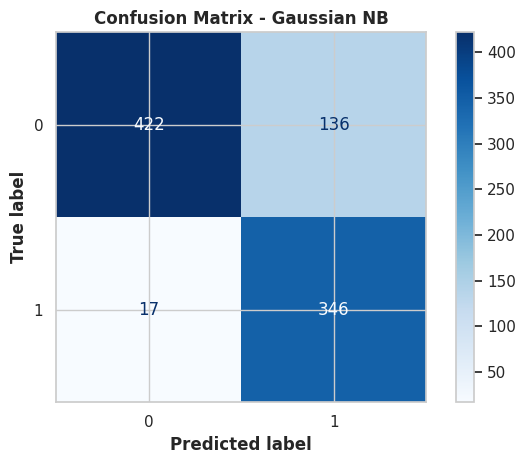

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/roc_curve_Gaussian_NB.eps


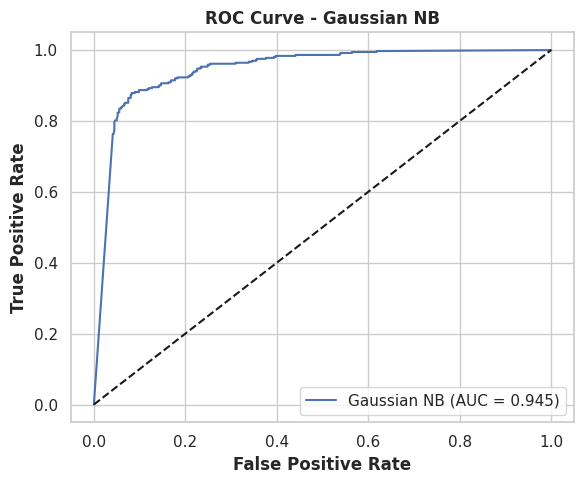

Saved: figures/pr_curve_Gaussian_NB.eps


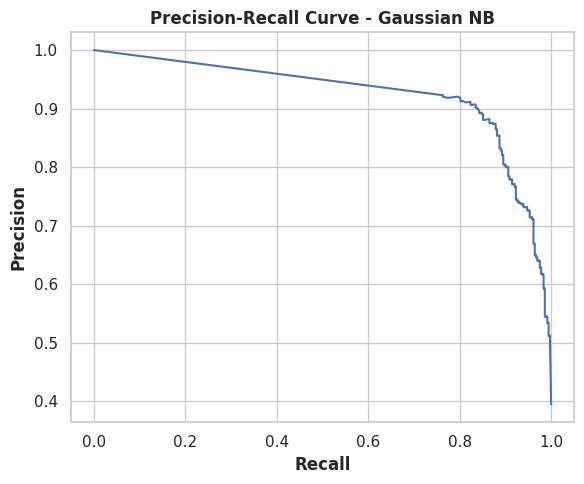

Saved: figures/confusion_matrix_Multinomial_NB.eps


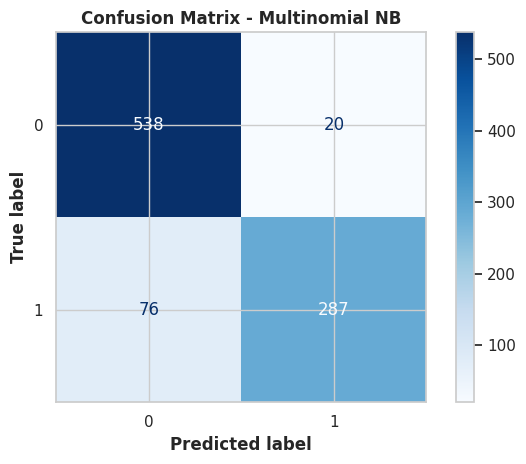

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/roc_curve_Multinomial_NB.eps


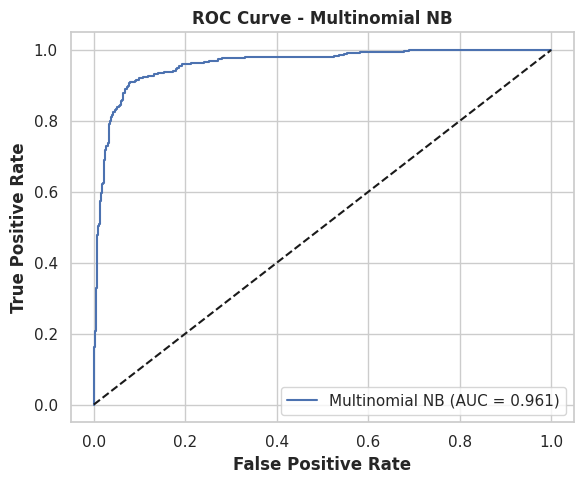

Saved: figures/pr_curve_Multinomial_NB.eps


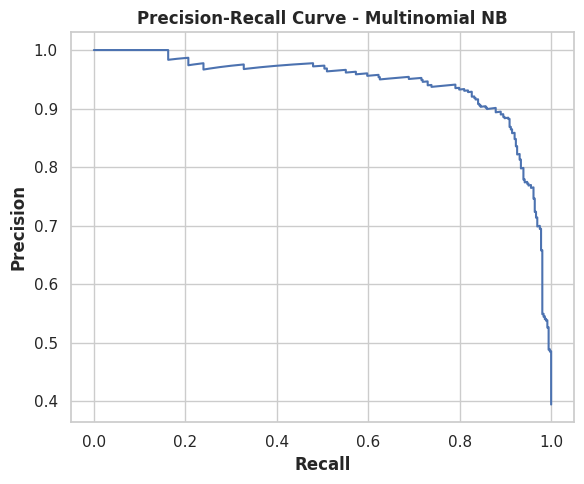

Saved: figures/confusion_matrix_Bernoulli_NB.eps


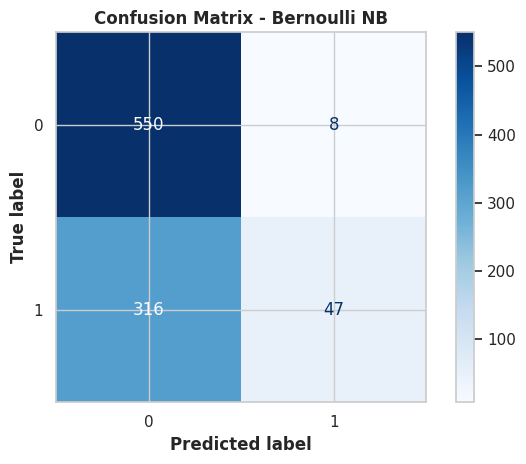

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/roc_curve_Bernoulli_NB.eps


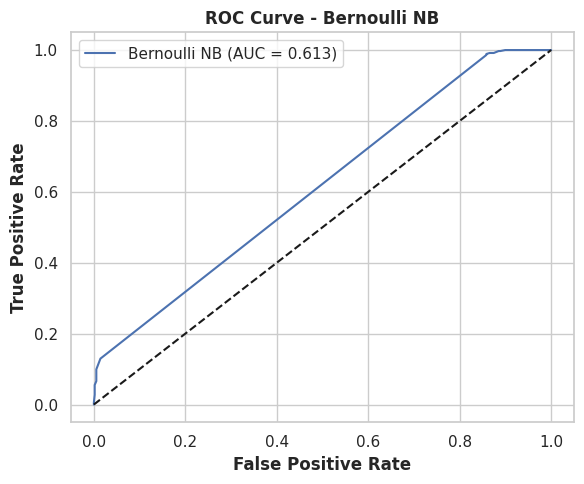

Saved: figures/pr_curve_Bernoulli_NB.eps


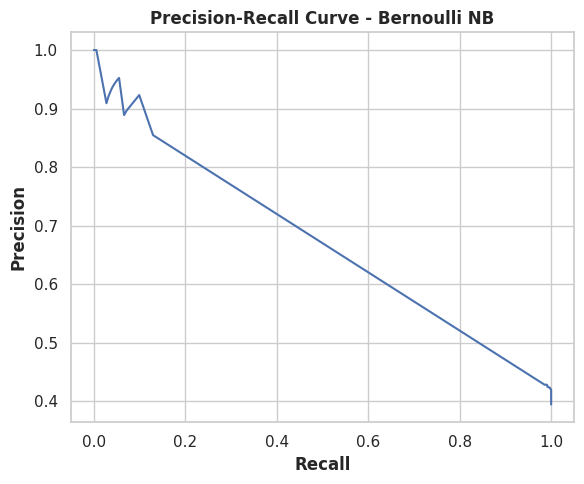

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s),Pred Time (s)
0,Gaussian NB,0.833876,0.717842,0.953168,0.818935,0.944926,0.006905,0.002901
1,Multinomial NB,0.895765,0.934853,0.790634,0.856716,0.961191,0.008213,0.002463
2,Bernoulli NB,0.648208,0.854545,0.129477,0.224880,0.613496,0.008764,0.002974


In [77]:
gaussian_model = Pipeline([
    ("clf", GaussianNB())
])

multinomial_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", MultinomialNB())
])

bernoulli_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("bin", Binarizer(threshold=0.5)),
    ("clf", BernoulliNB())
])

nb_results = []
nb_results.append(evaluate_pipeline(gaussian_model, "Gaussian NB", X_train, X_test, y_train, y_test, make_plots=True))
nb_results.append(evaluate_pipeline(multinomial_model, "Multinomial NB", X_train, X_test, y_train, y_test, make_plots=True))
nb_results.append(evaluate_pipeline(bernoulli_model, "Bernoulli NB", X_train, X_test, y_train, y_test, make_plots=True))

nb_df = pd.DataFrame(nb_results)
display(nb_df)

# Cell 7: Naïve Bayes Comparison Table and Bar Chart

Saved: figures/naive_bayes_accuracy_comparison.eps


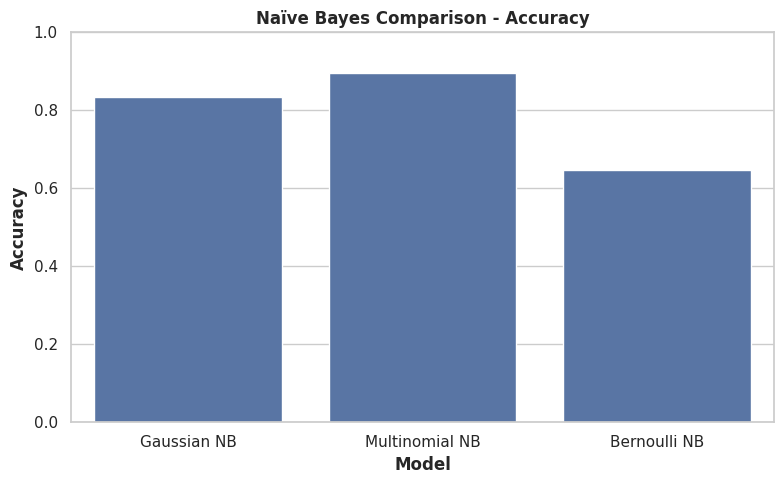

In [78]:
plt.figure(figsize=(8, 5))
sns.barplot(data=nb_df, x="Model", y="Accuracy")
plt.title("Naïve Bayes Comparison - Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
save_current_plot("naive_bayes_accuracy_comparison")
plt.show()

# Cell 8: KNN for Different Values of k

,k,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,0.892508,0.860656,0.867769,0.864198,0.888185
1,3,0.900109,0.881690,0.862259,0.871866,0.934272
2,5,0.903366,0.884831,0.867769,0.876217,0.944395
3,7,0.899023,0.879213,0.862259,0.870654,0.947557
4,9,0.894680,0.875706,0.853994,0.864714,0.951282
5,11,0.896851,0.882857,0.851240,0.866760,0.953667


Saved: figures/accuracy_vs_k.eps


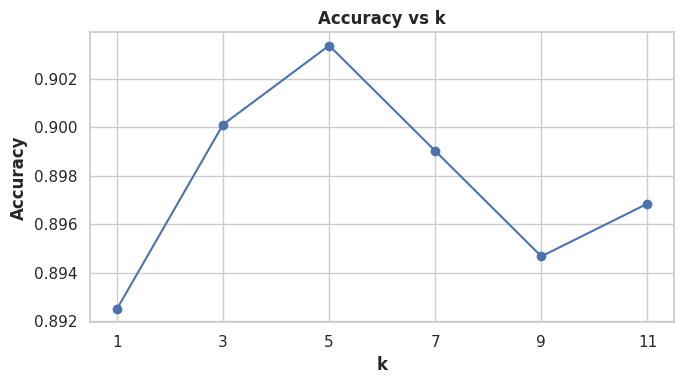

In [79]:
k_values = [1, 3, 5, 7, 9, 11]
knn_rows = []

for k in k_values:
    knn_model = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    result = evaluate_pipeline(knn_model, f"KNN (k={k})", X_train, X_test, y_train, y_test, make_plots=False)
    result["k"] = k
    knn_rows.append(result)

knn_df = pd.DataFrame(knn_rows)
display(knn_df[["k", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]])

plt.figure(figsize=(7, 4))
plt.plot(knn_df["k"], knn_df["Accuracy"], marker="o")
plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.tight_layout()
save_current_plot("accuracy_vs_k")
plt.show()

# Cell 9: Best k from KNN

In [80]:
best_k = int(knn_df.loc[knn_df["Accuracy"].idxmax(), "k"])
print("Best k =", best_k)

Best k = 5


# Cell 10: GridSearchCV for KNN

In [81]:
knn_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", KNeighborsClassifier())
])

param_grid = {
    "clf__n_neighbors": [1, 3, 5, 7, 9, 11],
    "clf__weights": ["uniform", "distance"],
    "clf__algorithm": ["brute", "kd_tree", "ball_tree"],
    "clf__metric": ["minkowski"],
    "clf__p": [1, 2]
}

grid_search = GridSearchCV(
    knn_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start = time.perf_counter()
grid_search.fit(X_train, y_train)
grid_time = time.perf_counter() - start

print("GridSearchCV Best Params:", grid_search.best_params_)
print("GridSearchCV Best CV Accuracy:", grid_search.best_score_)
print("GridSearchCV Time:", grid_time)

GridSearchCV Best Params: {'clf__algorithm': 'brute', 'clf__metric': 'minkowski', 'clf__n_neighbors': 7, 'clf__p': 1, 'clf__weights': 'distance'}
GridSearchCV Best CV Accuracy: 0.9163043478260869
GridSearchCV Time: 18.07740886800002


# Cell 11: RandomizedSearchCV for KNN

In [82]:
param_dist = {
    "clf__n_neighbors": [1, 3, 5, 7, 9, 11],
    "clf__weights": ["uniform", "distance"],
    "clf__algorithm": ["brute", "kd_tree", "ball_tree"],
    "clf__metric": ["minkowski"],
    "clf__p": [1, 2]
}

random_search = RandomizedSearchCV(
    knn_pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

start = time.perf_counter()
random_search.fit(X_train, y_train)
random_time = time.perf_counter() - start

print("RandomizedSearchCV Best Params:", random_search.best_params_)
print("RandomizedSearchCV Best CV Accuracy:", random_search.best_score_)
print("RandomizedSearchCV Time:", random_time)

RandomizedSearchCV Best Params: {'clf__weights': 'uniform', 'clf__p': 1, 'clf__n_neighbors': 3, 'clf__metric': 'minkowski', 'clf__algorithm': 'kd_tree'}
RandomizedSearchCV Best CV Accuracy: 0.9054347826086955
RandomizedSearchCV Time: 2.15677863899964


# Cell 12: GridSearchCV vs RandomizedSearchCV Table

In [83]:
tuning_df = pd.DataFrame([
    {
        "Parameter": "Best k",
        "GridSearchCV": grid_search.best_params_["clf__n_neighbors"],
        "RandomizedSearchCV": random_search.best_params_["clf__n_neighbors"]
    },
    {
        "Parameter": "Metric",
        "GridSearchCV": grid_search.best_params_["clf__metric"],
        "RandomizedSearchCV": random_search.best_params_["clf__metric"]
    },
    {
        "Parameter": "Weights",
        "GridSearchCV": grid_search.best_params_["clf__weights"],
        "RandomizedSearchCV": random_search.best_params_["clf__weights"]
    },
    {
        "Parameter": "Algorithm",
        "GridSearchCV": grid_search.best_params_["clf__algorithm"],
        "RandomizedSearchCV": random_search.best_params_["clf__algorithm"]
    },
    {
        "Parameter": "CV Accuracy",
        "GridSearchCV": grid_search.best_score_,
        "RandomizedSearchCV": random_search.best_score_
    },
    {
        "Parameter": "Execution Time (s)",
        "GridSearchCV": grid_time,
        "RandomizedSearchCV": random_time
    }
])

display(tuning_df)

,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,7,3
1,Metric,minkowski,minkowski
2,Weights,distance,uniform
3,Algorithm,brute,kd_tree
4,CV Accuracy,0.916304,0.905435
5,Execution Time (s),18.077409,2.156779


# Cell 13: GridSearchCV Heatmap

Saved: figures/gridsearch_heatmap.eps


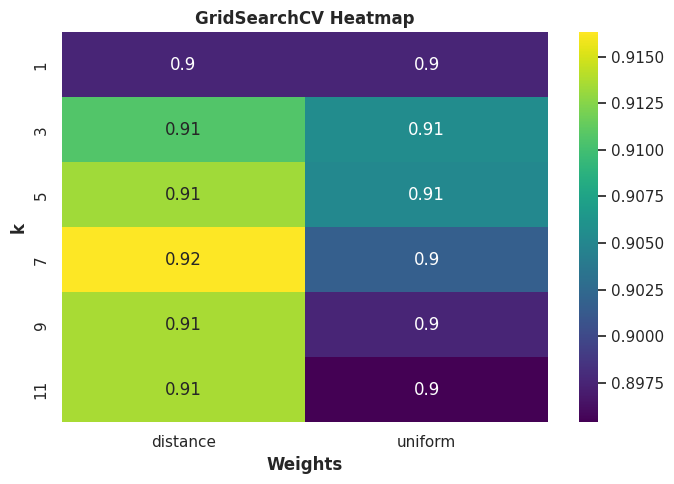

In [84]:
grid_results = pd.DataFrame(grid_search.cv_results_)

heatmap_data = grid_results.pivot_table(
    index="param_clf__n_neighbors",
    columns="param_clf__weights",
    values="mean_test_score",
    aggfunc="max"
)

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, cmap="viridis")
plt.title("GridSearchCV Heatmap")
plt.xlabel("Weights")
plt.ylabel("k")
plt.tight_layout()
save_current_plot("gridsearch_heatmap")
plt.show()

# Cell 14: RandomizedSearchCV Score Distribution

Saved: figures/randomizedsearch_score_distribution.eps


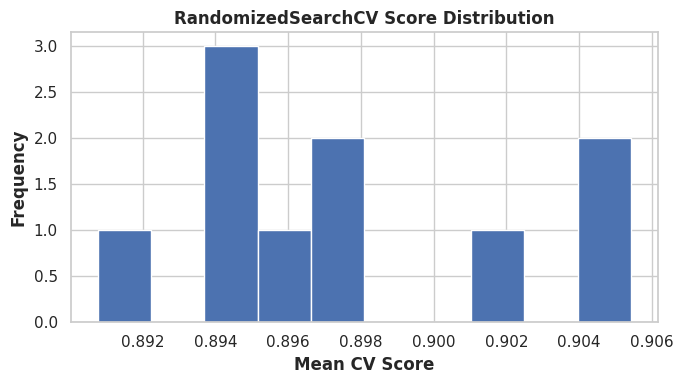

In [85]:
random_results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(7, 4))
plt.hist(random_results["mean_test_score"], bins=10)
plt.title("RandomizedSearchCV Score Distribution")
plt.xlabel("Mean CV Score")
plt.ylabel("Frequency")
plt.tight_layout()
save_current_plot("randomizedsearch_score_distribution")
plt.show()

# Cell 15: Best KNN Model from Search

In [86]:
best_knn = grid_search.best_estimator_ if grid_search.best_score_ >= random_search.best_score_ else random_search.best_estimator_
print("Selected Best KNN Model:", best_knn)

Selected Best KNN Model: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('clf',
                 KNeighborsClassifier(algorithm='brute', n_neighbors=7, p=1,
                                      weights='distance'))])


# Cell 16: KDTree vs BallTree

In [87]:
best_params = grid_search.best_params_ if grid_search.best_score_ >= random_search.best_score_ else random_search.best_params_

best_k_tree = best_params["clf__n_neighbors"]
best_weights_tree = best_params["clf__weights"]
best_p_tree = best_params["clf__p"]

tree_rows = []

for algo in ["kd_tree", "ball_tree"]:
    tree_model = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=best_k_tree,
            weights=best_weights_tree,
            algorithm=algo,
            metric="minkowski",
            p=best_p_tree
        ))
    ])
    result = evaluate_pipeline(tree_model, f"KNN-{algo}", X_train, X_test, y_train, y_test, make_plots=False)
    result["Algorithm"] = algo
    tree_rows.append(result)

tree_df = pd.DataFrame(tree_rows)
display(tree_df[["Algorithm", "Accuracy", "Train Time (s)", "Pred Time (s)"]])

,Algorithm,Accuracy,Train Time (s),Pred Time (s)
0,kd_tree,0.917481,0.022283,0.215112
1,ball_tree,0.917481,0.013717,0.179526


# Cell 17: 5-Fold Cross Validation

In [88]:
best_knn_cv = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=best_k_tree,
        weights=best_weights_tree,
        algorithm=best_knn.named_steps["clf"].algorithm if hasattr(best_knn.named_steps["clf"], "algorithm") else "auto",
        metric="minkowski",
        p=best_p_tree
    ))
])

cv_models = {
    "Gaussian NB": gaussian_model,
    "Multinomial NB": multinomial_model,
    "Bernoulli NB": bernoulli_model,
    "Best KNN": best_knn
}

cv_rows = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    cv_rows.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Average": scores.mean()
    })

cv_df = pd.DataFrame(cv_rows)
display(cv_df)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Gaussian NB,0.850163,0.870652,0.855435,0.852174,0.700000,0.825685
1,Multinomial NB,0.866450,0.886957,0.873913,0.907609,0.853261,0.877638
2,Bernoulli NB,0.622150,0.631522,0.634783,0.640217,0.620652,0.629865
3,Best KNN,0.881650,0.897826,0.929348,0.908696,0.826087,0.888721


# Cell 18: Cross-Validation Accuracy Bar Chart

Saved: figures/cross_validation_accuracy.eps


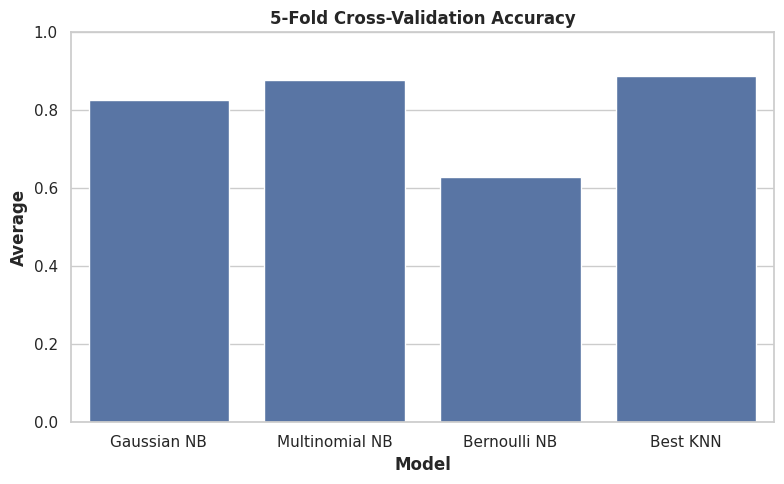

In [89]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cv_df, x="Model", y="Average")
plt.title("5-Fold Cross-Validation Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
save_current_plot("cross_validation_accuracy")
plt.show()

# Cell 19: Experimental Time Analysis

Saved: figures/confusion_matrix_Best_KNN.eps


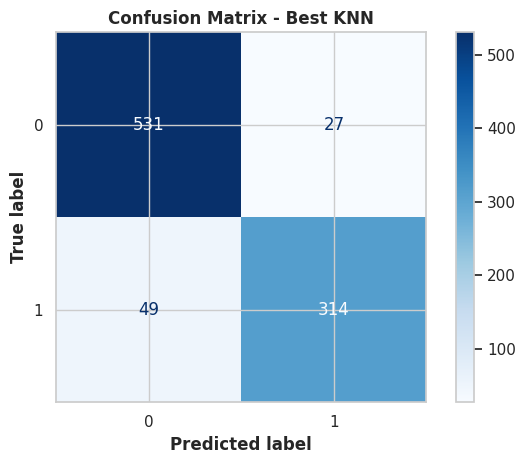

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/roc_curve_Best_KNN.eps


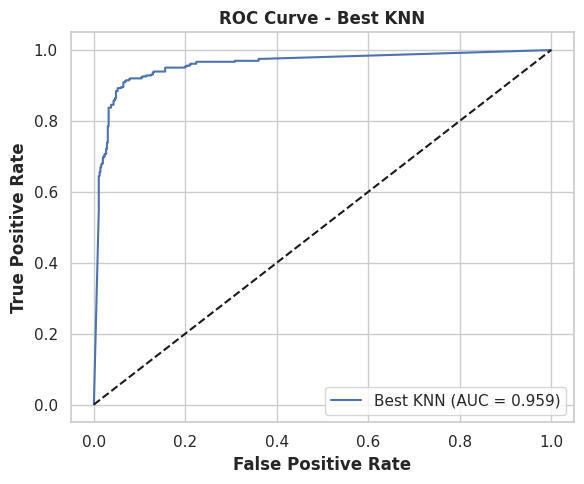

Saved: figures/pr_curve_Best_KNN.eps


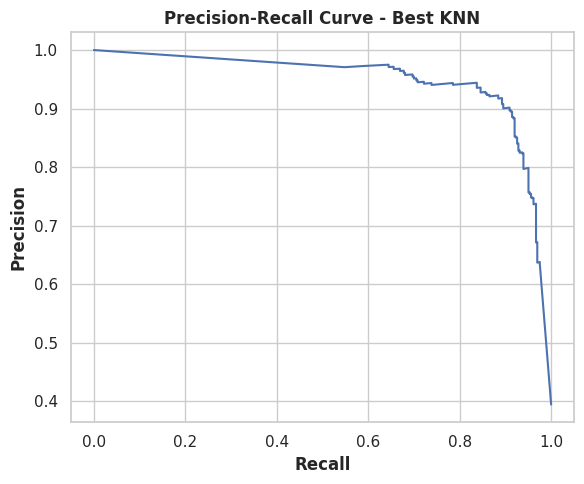

,Model,Train Time (s),Pred Time (s)
0,Gaussian NB,0.006289,0.002403
1,Multinomial NB,0.005920,0.002284
2,Bernoulli NB,0.007567,0.002920
3,Best KNN,0.005674,0.090818


Saved: figures/training_time_comparison.eps


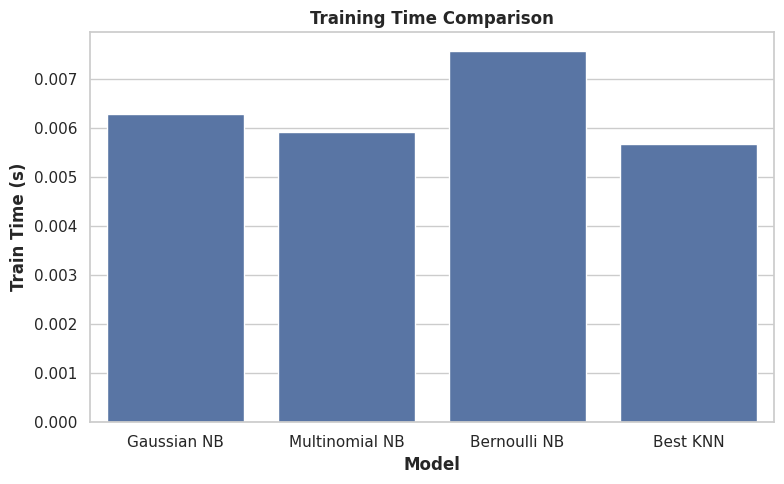

Saved: figures/prediction_time_comparison.eps


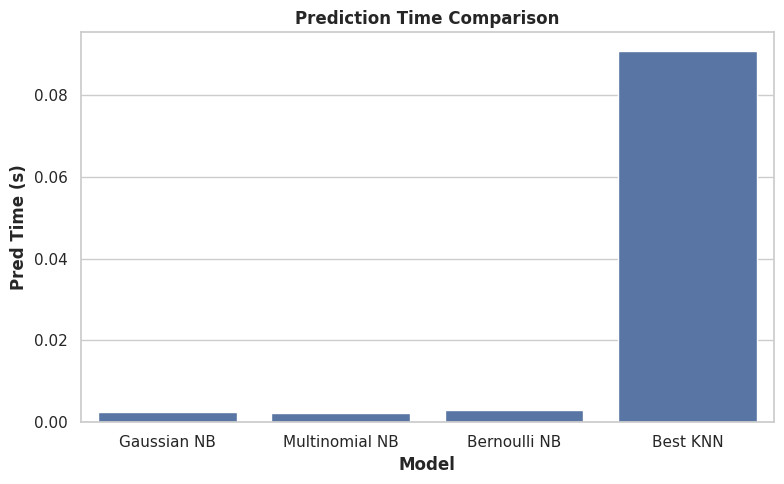

In [90]:
best_knn_final = best_knn

time_rows = []
time_rows.append(evaluate_pipeline(gaussian_model, "Gaussian NB", X_train, X_test, y_train, y_test, make_plots=False))
time_rows.append(evaluate_pipeline(multinomial_model, "Multinomial NB", X_train, X_test, y_train, y_test, make_plots=False))
time_rows.append(evaluate_pipeline(bernoulli_model, "Bernoulli NB", X_train, X_test, y_train, y_test, make_plots=False))
time_rows.append(evaluate_pipeline(best_knn_final, "Best KNN", X_train, X_test, y_train, y_test, make_plots=True))

time_df = pd.DataFrame(time_rows)
display(time_df[["Model", "Train Time (s)", "Pred Time (s)"]])

plt.figure(figsize=(8, 5))
sns.barplot(data=time_df, x="Model", y="Train Time (s)")
plt.title("Training Time Comparison")
plt.tight_layout()
save_current_plot("training_time_comparison")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=time_df, x="Model", y="Pred Time (s)")
plt.title("Prediction Time Comparison")
plt.tight_layout()
save_current_plot("prediction_time_comparison")
plt.show()

# Cell 20: Theoretical Time Complexity Table

In [91]:
complexity_df = pd.DataFrame([
    {"Algorithm": "Naïve Bayes", "Training": "O(nd)", "Prediction": "O(d)"},
    {"Algorithm": "KNN (Brute)", "Training": "O(1)", "Prediction": "O(nd)"},
    {"Algorithm": "KDTree", "Training": "O(n log n)", "Prediction": "O(log n) avg"},
    {"Algorithm": "BallTree", "Training": "O(n log n)", "Prediction": "O(log n) avg"}
])

display(complexity_df)

,Algorithm,Training,Prediction
0,Naïve Bayes,O(nd),O(d)
1,KNN (Brute),O(1),O(nd)
2,KDTree,O(n log n),O(log n) avg
3,BallTree,O(n log n),O(log n) avg


# Cell 21: Final Comparison Table

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gaussian NB,0.833876,0.717842,0.953168,0.818935,0.944926
1,Multinomial NB,0.895765,0.934853,0.790634,0.856716,0.961191
2,Bernoulli NB,0.648208,0.854545,0.129477,0.224880,0.613496
3,KNN (k=5),0.903366,0.884831,0.867769,0.876217,0.944395


Saved: figures/classifier_comparison_accuracy.eps


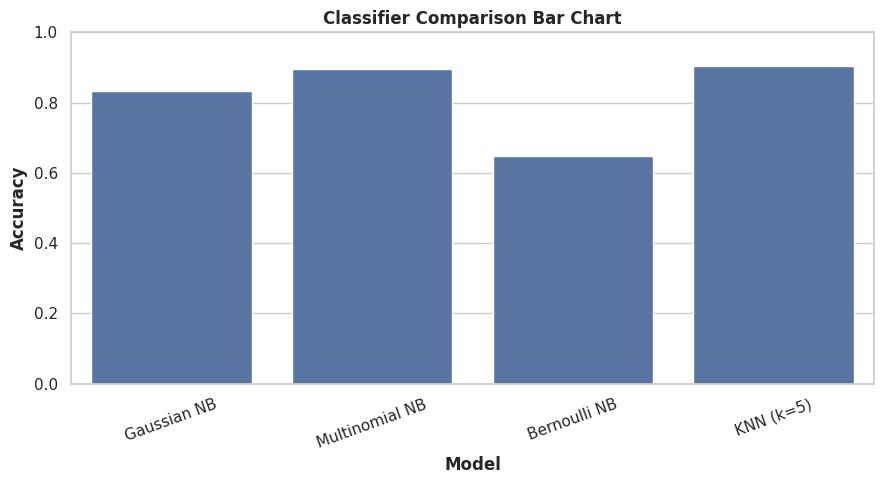

In [92]:
final_compare = pd.concat([
    nb_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]],
    knn_df.loc[knn_df["k"] == best_k, ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].assign(Model=f"KNN (k={best_k})")
], ignore_index=True)

display(final_compare[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]])

plt.figure(figsize=(9, 5))
sns.barplot(data=final_compare, x="Model", y="Accuracy")
plt.title("Classifier Comparison Bar Chart")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
save_current_plot("classifier_comparison_accuracy")
plt.show()

# Additional Tasks

# Cell 22: Different train-test splits

In [93]:
split_rows = []
for ts in [0.1, 0.2, 0.3]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, random_state=42, stratify=y)
    r = evaluate_pipeline(best_knn_final, f"split={int((1-ts)*100)}/{int(ts*100)}", Xtr, Xte, ytr, yte, make_plots=False)
    split_rows.append(r)

split_df = pd.DataFrame(split_rows)
display(split_df[["Model", "Accuracy", "F1-Score"]])

,Model,Accuracy,F1-Score
0,split=90/10,0.900217,0.867816
1,split=80/20,0.917481,0.892045
2,split=70/30,0.924692,0.902072


# Cell 23: Euclidean vs Manhattan distance

In [94]:
dist_rows = []
for p, name in [(1, "Manhattan"), (2, "Euclidean")]:
    m = Pipeline([("scaler", MinMaxScaler()), ("clf", KNeighborsClassifier(n_neighbors=best_k, p=p))])
    r = evaluate_pipeline(m, name, X_train, X_test, y_train, y_test, make_plots=False)
    dist_rows.append(r)

dist_df = pd.DataFrame(dist_rows)
display(dist_df[["Model", "Accuracy", "F1-Score"]])

,Model,Accuracy,F1-Score
0,Manhattan,0.904452,0.873563
1,Euclidean,0.903366,0.876217


# Cell 24: Weighted vs uniform KNN

In [95]:
weight_rows = []
for w in ["uniform", "distance"]:
    m = Pipeline([("scaler", MinMaxScaler()), ("clf", KNeighborsClassifier(n_neighbors=best_k, weights=w))])
    r = evaluate_pipeline(m, w, X_train, X_test, y_train, y_test, make_plots=False)
    weight_rows.append(r)

weight_df = pd.DataFrame(weight_rows)
display(weight_df[["Model", "Accuracy", "F1-Score"]])

,Model,Accuracy,F1-Score
0,uniform,0.903366,0.876217
1,distance,0.907709,0.882108


In [96]:
!zip -r output.zip /kaggle/working/figures

updating: kaggle/working/figures/ (stored 0%)
updating: kaggle/working/figures/roc_curve_Best_KNN.eps (deflated 65%)
updating: kaggle/working/figures/histogram_word_freq_remove.eps (deflated 71%)
updating: kaggle/working/figures/confusion_matrix_Bernoulli_NB.eps (deflated 99%)
updating: kaggle/working/figures/roc_curve_Bernoulli_NB.eps (deflated 65%)
updating: kaggle/working/figures/confusion_matrix_Gaussian_NB.eps (deflated 99%)
updating: kaggle/working/figures/classifier_comparison_accuracy.eps (deflated 64%)
updating: kaggle/working/figures/accuracy_vs_k.eps (deflated 66%)
updating: kaggle/working/figures/histogram_word_freq_your.eps (deflated 70%)
updating: kaggle/working/figures/pr_curve_Multinomial_NB.eps (deflated 65%)
updating: kaggle/working/figures/boxplot_char_freq__24.eps (deflated 71%)
updating: kaggle/working/figures/training_time_comparison.eps (deflated 65%)
updating: kaggle/working/figures/histogram_word_freq_000.eps (deflated 70%)
updating: kaggle/working/figures/naiv